# Lane detection with classical CV



In [1]:
import cv2
import numpy as np
import glob, os
import matplotlib.pyplot as plt

In [ ]:
train_dir = 'car_lane_dataset/train'
train_label_dir = 'car_lane_dataset/train_label'
val_dir = 'car_lane_dataset/val'
val_label_dir = 'car_lane_dataset/val_label'

train_imgs = sorted(glob.glob(os.path.join(train_dir, '*.png')))
val_imgs = sorted(glob.glob(os.path.join(val_dir, '*.png')))
print('train', len(train_imgs), 'val', len(val_imgs))
train_imgs[:3]

train 3075 val 129


['car_lane_dataset/train/Town04_Clear_Noon_09_09_2020_14_57_22_frame_0.png',
 'car_lane_dataset/train/Town04_Clear_Noon_09_09_2020_14_57_22_frame_10.png',
 'car_lane_dataset/train/Town04_Clear_Noon_09_09_2020_14_57_22_frame_1000.png']

car_lane_dataset/train/Town04_Clear_Noon_09_09_2020_14_57_22_frame_1937.png (512, 1024, 3)


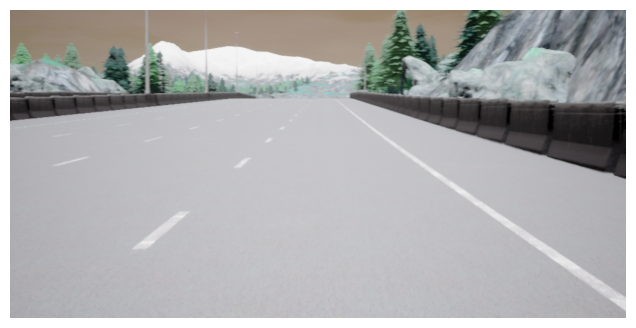

In [ ]:
img = cv2.imread(train_imgs[1000])
h, w = img.shape[:2]
print(train_imgs[1000], img.shape)

plt.figure(figsize=(9, 4))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

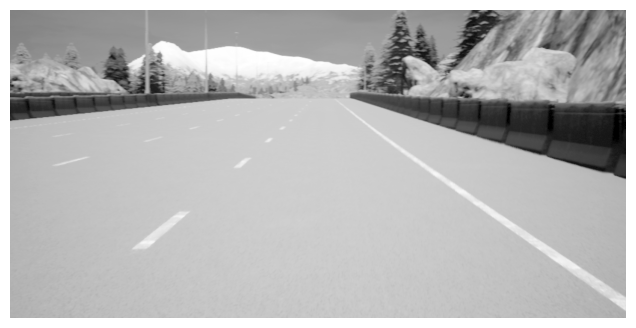

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(9, 4))
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

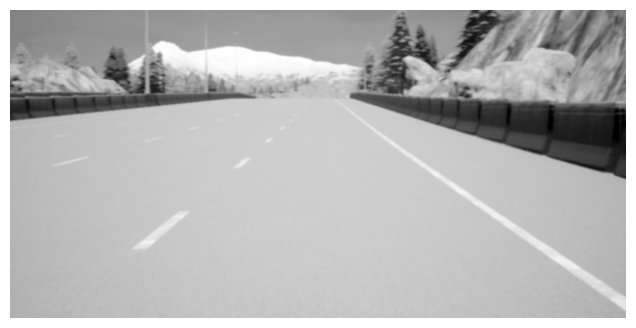

In [ ]:
k = 5
blur = cv2.GaussianBlur(gray, (k, k), 0)
plt.figure(figsize=(9, 4))
plt.imshow(blur, cmap='gray')
plt.axis('off')
plt.show()

### Isolate the bright markings

The CARLA road is low contrast so plain Canny finds nothing on the road surface. We threshold the bright pixels first, then Canny only sees the painted markings.

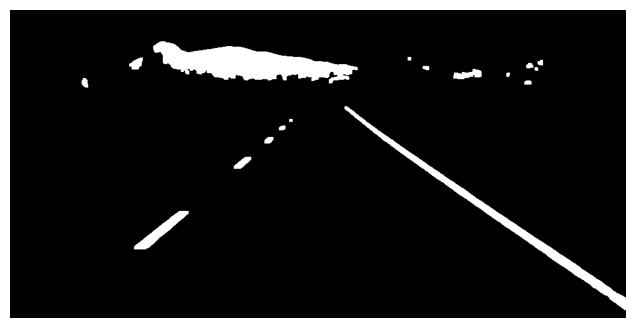

In [ ]:
wt = 200
mask_w = cv2.inRange(blur, wt, 255)
mask_w = cv2.morphologyEx(mask_w, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
plt.figure(figsize=(9, 4))
plt.imshow(mask_w, cmap='gray')
plt.axis('off')
plt.show()

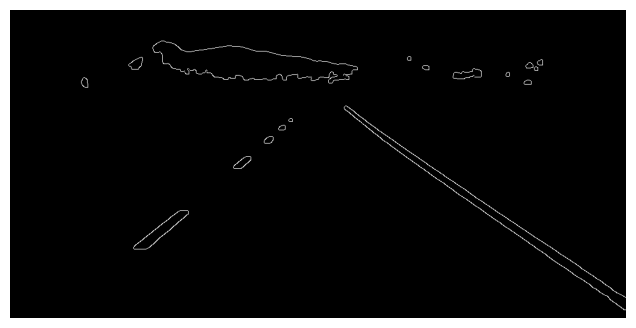

In [ ]:
lo = 50
hi = 150
edges = cv2.Canny(mask_w, lo, hi)
plt.figure(figsize=(9, 4))
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

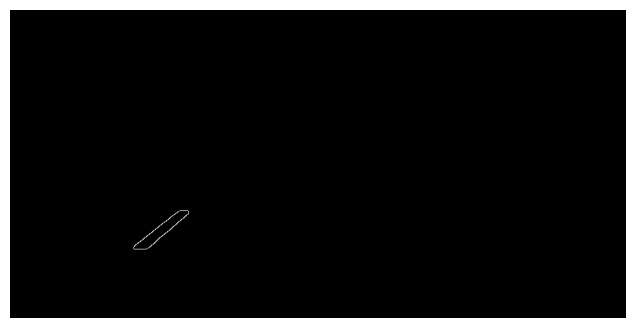

In [8]:
# trapezoid roi as ratios of w and h, images are 512 x 1024
top_y = 0.58   # horizon line
bl_x = 0.04    # bottom left
br_x = 0.99    # bottom right
tl_x = 0.30    # top left
tr_x = 0.70    # top right

verts = np.array([[
    (int(bl_x * w), h),
    (int(tl_x * w), int(top_y * h)),
    (int(tr_x * w), int(top_y * h)),
    (int(br_x * w), h),
]], dtype=np.int32)

roi_mask = np.zeros((h, w), np.uint8)
cv2.fillPoly(roi_mask, verts, 255)
roi = cv2.bitwise_and(edges, roi_mask)

plt.figure(figsize=(9, 4))
plt.imshow(roi, cmap='gray')
plt.axis('off')
plt.show()

segments 5


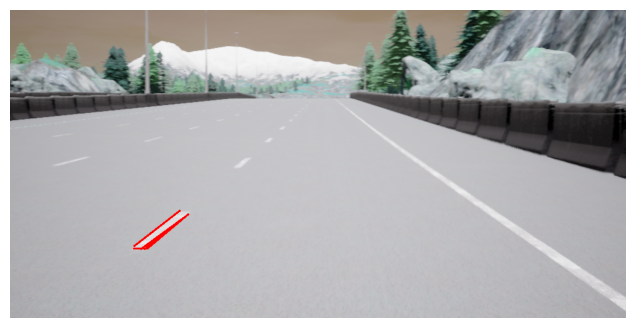

In [9]:
# hough params
rho = 2
theta = np.pi / 180
thresh = 20
min_len = 15
max_gap = 250

lines = cv2.HoughLinesP(roi, rho, theta, thresh, minLineLength=min_len, maxLineGap=max_gap)
print('segments', 0 if lines is None else len(lines))

raw = img.copy()
if lines is not None:
    for ln in lines:
        x1, y1, x2, y2 = ln[0]
        cv2.line(raw, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.figure(figsize=(9, 4))
plt.imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

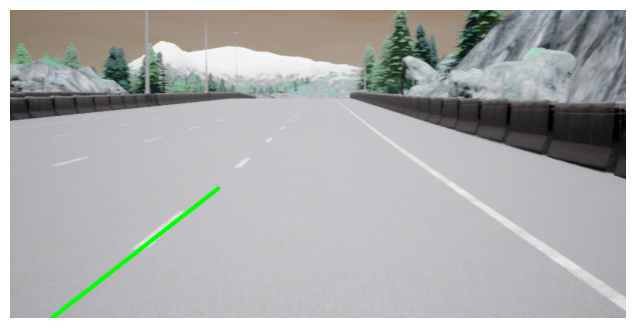

In [ ]:
# straight line fit, split by slope and average each side into one line
min_slope = 0.4

def lane_lines(lines, ih):
    left, right = [], []
    if lines is not None:
        for ln in lines:
            x1, y1, x2, y2 = ln[0]
            if x2 == x1:
                continue
            s = (y2 - y1) / (x2 - x1)
            if abs(s) < min_slope:   
                continue
            b = y1 - s * x1
            (left if s < 0 else right).append((s, b))
    yb, yt = ih, int(top_y * ih)
    out = []
    for grp in (left, right):
        if not grp:             
            out.append(None)
            continue
        s = np.mean([g[0] for g in grp])
        b = np.mean([g[1] for g in grp])
        out.append(np.array([[int((yb - b) / s), yb], [int((yt - b) / s), yt]]))
    return out[0], out[1]

def draw_lanes(im, lanes, color=(0, 255, 0)):
    out = im.copy()
    for pts in lanes:
        if pts is not None:
            cv2.polylines(out, [pts.reshape(-1, 1, 2)], False, color, 6)
    return out

left, right = lane_lines(lines, h)
plt.figure(figsize=(9, 4))
plt.imshow(cv2.cvtColor(draw_lanes(img, (left, right)), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### Degree 2 polyfit variant

Same markings, but fit x as a degree 2 polynomial of y per side so the lane can bend. We use the straight fit as a corridor, grab the marking pixels inside it, and fit a curve through them.

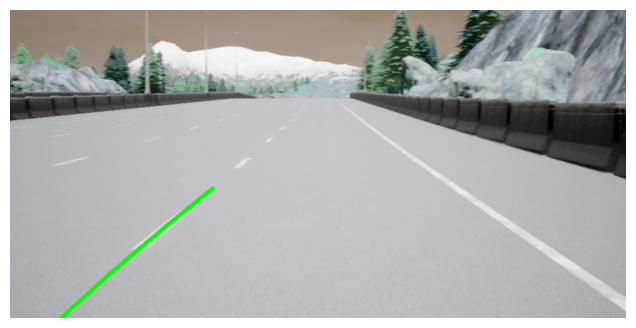

In [ ]:
# polyfit variant, fit a degree 2 curve on the marking pixels of each side
def lane_curves(lines, mw, ih):
    l, r = lane_lines(lines, ih)        
    ys, xs = np.where(mw > 0)
    yb, yt = ih, int(top_y * ih)
    out = []
    for ln in (l, r):
        if ln is None:                  
            out.append(None)
            continue
        (x1, y1), (x2, y2) = ln
        sx = (x2 - x1) / (y2 - y1)
        xline = x1 + sx * (ys - y1)     
        sel = np.abs(xs - xline) < 60
        if sel.sum() < 30 or len(set(ys[sel].tolist())) < 3:
            out.append(None)
            continue
        c = np.polyfit(ys[sel], xs[sel], 2)
        yy = np.linspace(yt, yb, 30).astype(int)
        xx = np.polyval(c, yy).astype(int)
        out.append(np.column_stack([xx, yy]))
    return out[0], out[1]

mw_roi = cv2.bitwise_and(mask_w, roi_mask)
left_c, right_c = lane_curves(lines, mw_roi, h)
plt.figure(figsize=(9, 4))
plt.imshow(cv2.cvtColor(draw_lanes(img, (left_c, right_c)), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

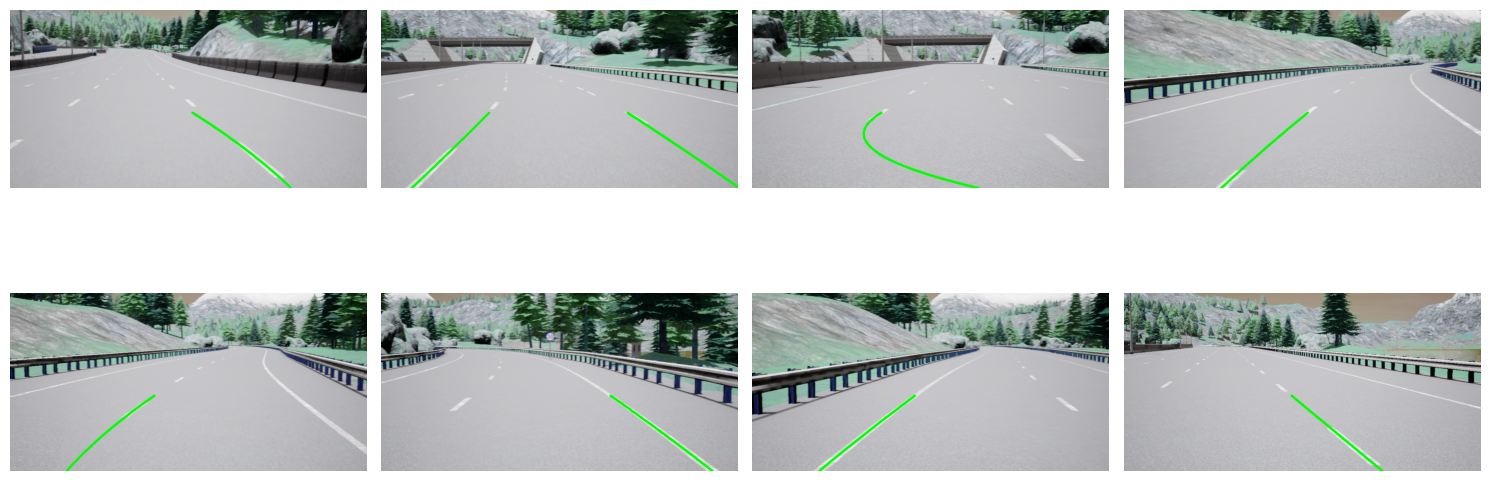

In [12]:
# detection core up to hough, returns the segments and the roi marking mask
def detect(im):
    ih, iw = im.shape[:2]
    g = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    g = cv2.GaussianBlur(g, (k, k), 0)
    m = cv2.inRange(g, wt, 255)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    e = cv2.Canny(m, lo, hi)
    v = np.array([[
        (int(bl_x * iw), ih),
        (int(tl_x * iw), int(top_y * ih)),
        (int(tr_x * iw), int(top_y * ih)),
        (int(br_x * iw), ih),
    ]], dtype=np.int32)
    rm = np.zeros((ih, iw), np.uint8)
    cv2.fillPoly(rm, v, 255)
    ls = cv2.HoughLinesP(cv2.bitwise_and(e, rm), rho, theta,
                         thresh, minLineLength=min_len, maxLineGap=max_gap)
    return ls, cv2.bitwise_and(m, rm)

def process_frame(im, mode='poly'):
    ls, mw = detect(im)
    if mode == 'poly':
        l, r = lane_curves(ls, mw, im.shape[0])
    else:
        l, r = lane_lines(ls, im.shape[0])
    return draw_lanes(im, (l, r))

# test the polyfit pipeline on a spread of train frames
idx = [100, 500, 900, 1300, 1700, 2100, 2500, 2900]
plt.figure(figsize=(15, 7))
for i, n in enumerate(idx):
    plt.subplot(2, 4, i + 1)
    plt.imshow(cv2.cvtColor(process_frame(cv2.imread(train_imgs[n]), 'poly'), cv2.COLOR_BGR2RGB))
    plt.axis('off')
plt.tight_layout()
plt.show()

### Evaluation on val

GT is a mask, class 1 is the left lane, class 2 the right. We run both fitters and print the numbers side by side. IoU compares the predicted line band against the dilated GT mask. Detection rate is the share of val frames with something found on both sides, the more honest measure here.

In [ ]:
# eval both fitters on val
def lane_mask(lanes, ih, iw, t=18):
    m = np.zeros((ih, iw), np.uint8)
    for pts in lanes:
        if pts is not None:
            cv2.polylines(m, [pts.reshape(-1, 1, 2)], False, 255, t)
    return m

def evaluate(mode):
    ious, both = [], 0
    for f in val_imgs:
        im = cv2.imread(f)
        ih, iw = im.shape[:2]
        lf = os.path.join(val_label_dir, os.path.basename(f).replace('.png', '_label.png'))
        lab = cv2.imread(lf, cv2.IMREAD_UNCHANGED)
        ls, mw = detect(im)
        if mode == 'poly':
            l, r = lane_curves(ls, mw, ih)
        else:
            l, r = lane_lines(ls, ih)
        if l is not None and r is not None:
            both += 1
        pred = lane_mask((l, r), ih, iw)
        gt = (((lab == 1) | (lab == 2)) * 255).astype(np.uint8)
        gt = cv2.dilate(gt, np.ones((9, 9), np.uint8))
        inter = np.logical_and(pred > 0, gt > 0).sum()
        union = np.logical_or(pred > 0, gt > 0).sum()
        if union > 0:
            ious.append(inter / union)
    return float(np.mean(ious)), 100 * both / len(val_imgs)

print('val frames', len(val_imgs))
print('%-14s %8s %9s' % ('mode', 'iou', 'detrate'))
for mode in ('line', 'poly'):
    iou, dr = evaluate(mode)
    print('%-14s %8.3f %8.1f%%' % (mode, iou, dr))

val frames 129
mode                iou   detrate


line              0.298     14.0%


poly              0.297     13.2%


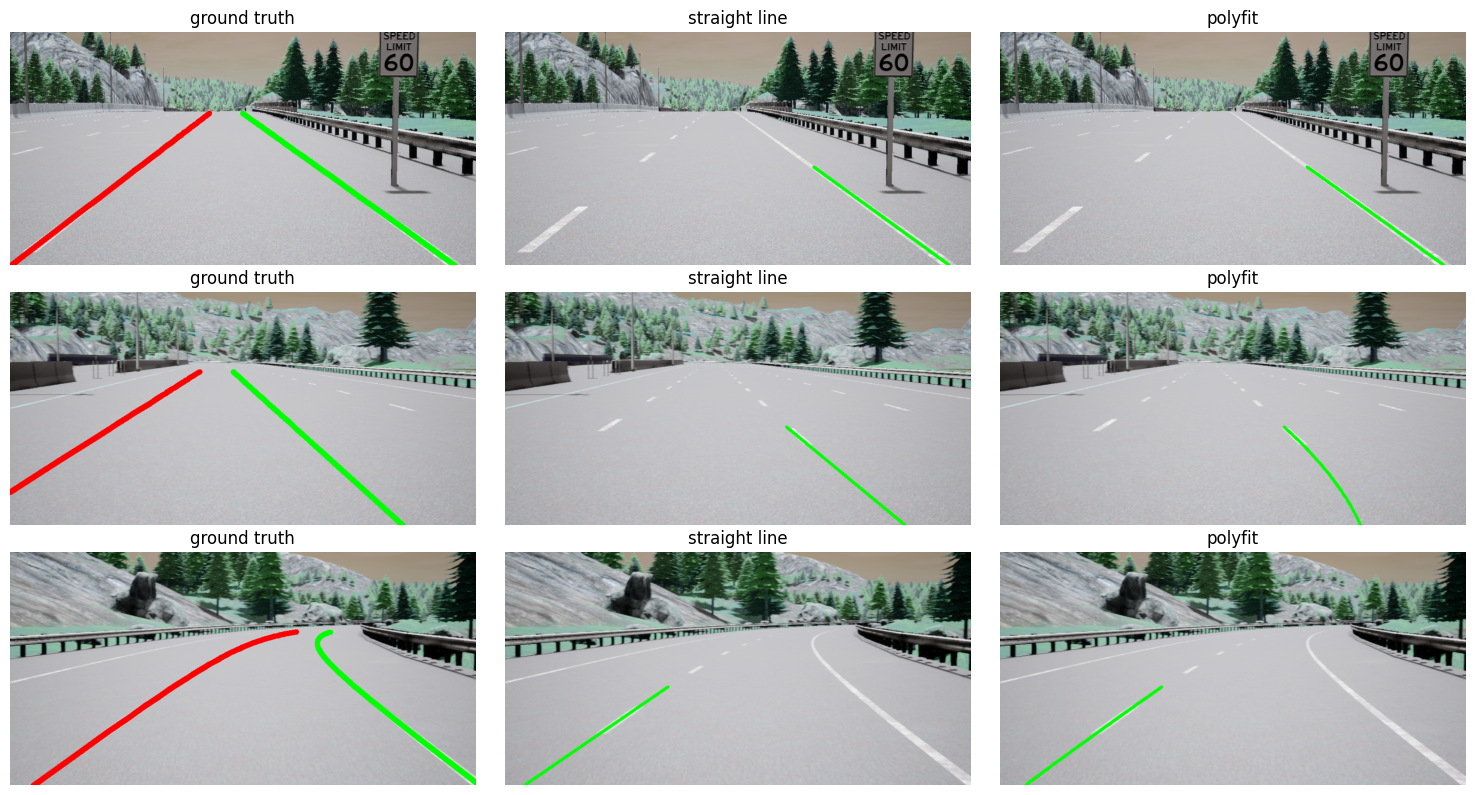

In [14]:
# gt vs both fitters on a few val frames
plt.figure(figsize=(15, 8))
for i, n in enumerate([10, 40, 90]):
    im = cv2.imread(val_imgs[n])
    lf = os.path.join(val_label_dir, os.path.basename(val_imgs[n]).replace('.png', '_label.png'))
    lab = cv2.imread(lf, cv2.IMREAD_UNCHANGED)
    gt = im.copy()
    gt[cv2.dilate((lab == 1).astype(np.uint8), np.ones((5, 5), np.uint8)) > 0] = (0, 0, 255)
    gt[cv2.dilate((lab == 2).astype(np.uint8), np.ones((5, 5), np.uint8)) > 0] = (0, 255, 0)
    panels = [('ground truth', gt),
              ('straight line', process_frame(im, 'line')),
              ('polyfit', process_frame(im, 'poly'))]
    for j, (title, frame) in enumerate(panels):
        plt.subplot(3, 3, 3 * i + j + 1)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
plt.tight_layout()
plt.show()

## What works and what fails

The pipeline picks up the painted dashed markings well when they are close to the car, so on clear stretches it gives a clean lane on at least one side. The degree 2 polyfit variant did not beat the straight line fit here, it ties it on val and ties it again even on the curved frames alone. The painted dashes only span a short stretch near the car, and over that short span a line and a curve sit almost on top of each other, so the curve has nothing extra to grip and still extrapolates blind up to the horizon. The bigger problem is the unpainted side. One ego lane boundary in most frames sits on bare asphalt with no marking, so there are no edges to detect there, and no fit, straight or curved, can recover a line from zero points. That is the cleanest version of the story, the fit shape barely matters when half the lane has nothing to see. Shadows, lighting shifts and markings lost near the horizon stay hard for both variants. A deep learning lane segmentation model would do better because it learns lane appearance and road context from data, so it can infer an unpainted boundary from surrounding cues instead of depending on visible paint.